# Ocean Mass and Bottom Pressure Algorithms

These notes introduce the main processing ideas behind satellite gravimetry products used in oceanography. The goal is not to reproduce an operational GRACE solution, but to build intuition for how changes in satellite motion become gravity anomalies, mass anomalies, and ocean bottom pressure fields.

## Motivation

GRACE and GRACE-FO do not directly measure ocean bottom pressure. They precisely measure changes in the distance between two satellites. Those tracking data are combined with orbit models and corrections, then inverted to estimate changes in Earth's gravity field and mass distribution.

### Learning Objectives

By the end of this notebook, you should be able to:

- Describe the role of harmonic functions in representing spatial fields on Earth.
- Explain the difference between spherical-harmonic and mascon-style gravimetry products.
- Convert equivalent water height to bottom pressure.
- Recognize common processing issues such as smoothing, leakage, and removal of non-ocean signals.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Step 1: Representing Spatial Variability with Harmonics

The gravimetry lecture uses Fourier series as a mathematical sidebar. The basic idea is that complicated spatial patterns can be represented as sums of simpler waves. On a sphere, the analogous basis functions are **spherical harmonics**.

The example below uses a 1D Fourier-style reconstruction to show the concept without needing spherical-harmonic software.

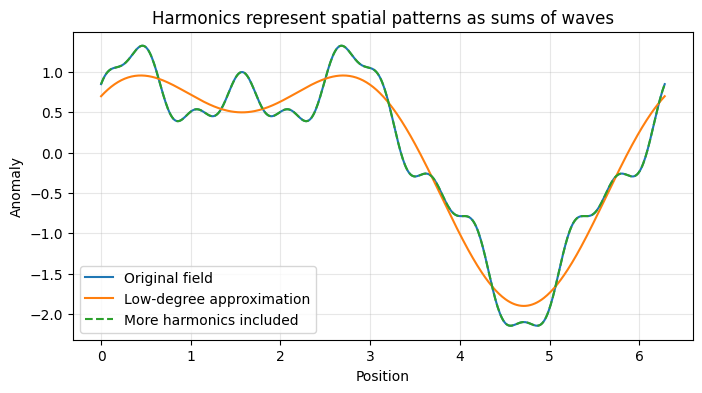

In [2]:
# Build a simple 1D field from several harmonics.
x = np.linspace(0, 2*np.pi, 500)
true_field = (
    1.2*np.sin(x) +
    0.7*np.cos(2*x) +
    0.35*np.sin(5*x) +
    0.15*np.cos(12*x)
)

recon_low = 1.2*np.sin(x) + 0.7*np.cos(2*x)
recon_high = recon_low + 0.35*np.sin(5*x) + 0.15*np.cos(12*x)

plt.figure(figsize=(8, 4))
plt.plot(x, true_field, label='Original field')
plt.plot(x, recon_low, label='Low-degree approximation')
plt.plot(x, recon_high, '--', label='More harmonics included')
plt.xlabel('Position')
plt.ylabel('Anomaly')
plt.title('Harmonics represent spatial patterns as sums of waves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Step 2: From Tracking Data to Gravity Anomalies

A complete GRACE processing chain includes many steps:

1. Measure inter-satellite range and range-rate very precisely.
2. Estimate satellite positions and velocities.
3. Correct for non-gravitational accelerations and known gravitational effects.
4. Remove or model tides, atmosphere, static gravity, and third-body effects from the Sun and Moon.
5. Solve for time-variable gravity anomalies.
6. Convert gravity anomalies into mass anomalies.

This notebook uses synthetic examples to illustrate the last two steps.

## Step 3: Mass Anomaly Fields

A positive ocean mass anomaly means more water mass is present than the reference state. A negative anomaly means less water mass. In gridded products, mass is often expressed as **equivalent water height**: the thickness of water that would produce the observed mass anomaly.

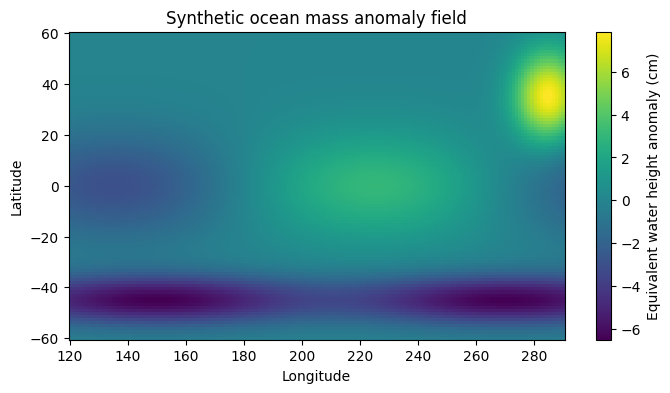

In [3]:
# Create a synthetic equivalent-water-height anomaly field.
ny, nx = 100, 160
lon = np.linspace(120, 290, nx)
lat = np.linspace(-60, 60, ny)
LON, LAT = np.meshgrid(lon, lat)

western_boundary = 8*np.exp(-((LON-285)/12)**2 - ((LAT-35)/18)**2)
southern_ocean = -5*np.exp(-((LAT+45)/10)**2) * (1 + 0.3*np.sin(np.deg2rad(3*LON)))
tropical = 3*np.sin(np.deg2rad(2*LON)) * np.exp(-(LAT/22)**2)
ewh_cm = western_boundary + southern_ocean + tropical

plt.figure(figsize=(8, 4))
plt.pcolormesh(lon, lat, ewh_cm, shading='auto')
plt.colorbar(label='Equivalent water height anomaly (cm)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Synthetic ocean mass anomaly field')
plt.show()

## Step 4: Smoothing and Leakage

GRACE-style products have coarse spatial resolution compared with optical, infrared, altimetry, or SAR imagery. Spatial smoothing is often needed to suppress noise, but smoothing spreads signals across boundaries. This spreading is called **leakage**.

For ocean applications, leakage from land hydrology, ice sheets, and coastlines can be especially important.

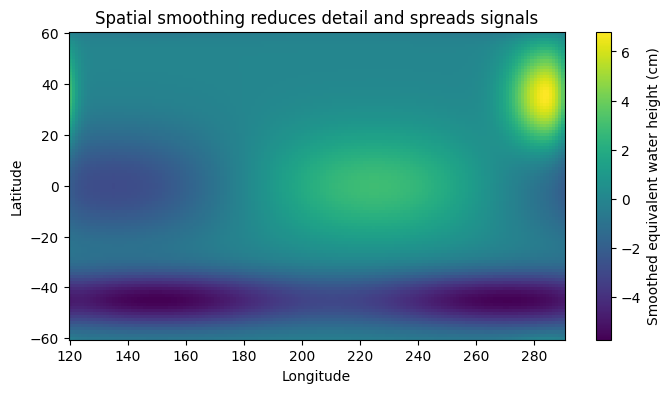

In [4]:
# A simple Gaussian-like smoothing using repeated nearest-neighbor averaging.
def smooth2d(arr, n=10):
    out = arr.copy()
    for _ in range(n):
        out = (
            out +
            np.roll(out, 1, axis=0) + np.roll(out, -1, axis=0) +
            np.roll(out, 1, axis=1) + np.roll(out, -1, axis=1)
        ) / 5.0
    return out

smoothed = smooth2d(ewh_cm, n=25)

plt.figure(figsize=(8, 4))
plt.pcolormesh(lon, lat, smoothed, shading='auto')
plt.colorbar(label='Smoothed equivalent water height (cm)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Spatial smoothing reduces detail and spreads signals')
plt.show()

## Step 5: Mascon Solutions

Instead of estimating a global set of spherical-harmonic coefficients and then converting them to mass, many modern products solve for mass changes directly in predefined surface regions called **mass concentration blocks**, or **mascons**.

A mascon solution treats mass change as being distributed among a finite set of regions. This can make it easier to apply geophysical constraints and reduce some types of leakage, although mascon products still require careful interpretation.

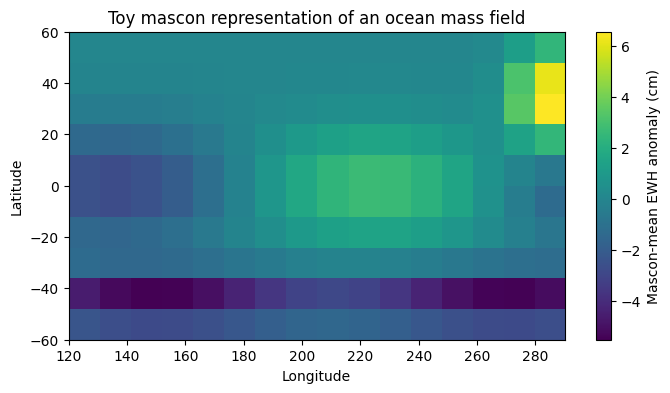

In [5]:
# Toy mascon averaging: aggregate the synthetic field into coarse blocks.
block_y, block_x = 10, 10
coarse = ewh_cm.reshape(ny//block_y, block_y, nx//block_x, block_x).mean(axis=(1, 3))

plt.figure(figsize=(8, 4))
plt.imshow(coarse, origin='lower', aspect='auto', extent=[lon.min(), lon.max(), lat.min(), lat.max()])
plt.colorbar(label='Mascon-mean EWH anomaly (cm)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Toy mascon representation of an ocean mass field')
plt.show()

## Step 6: Equivalent Water Height to Ocean Bottom Pressure

For a small equivalent-water-height anomaly $\eta$, the pressure anomaly can be estimated as:

\begin{equation}
P' \approx \rho_w g \eta
\end{equation}

where $\rho_w$ is seawater density, $g$ is gravitational acceleration, and $\eta$ is in meters.

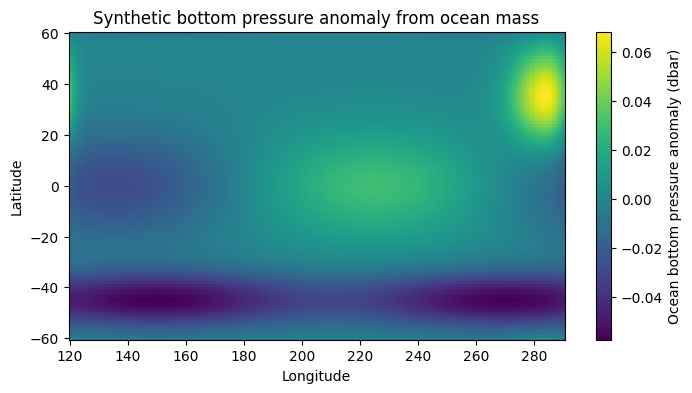

In [6]:
rho_w = 1025.0  # kg m^-3
g = 9.81       # m s^-2
eta_m = smoothed / 100.0
obp_pa = rho_w * g * eta_m
obp_dbar = obp_pa / 1e4

plt.figure(figsize=(8, 4))
plt.pcolormesh(lon, lat, obp_dbar, shading='auto')
plt.colorbar(label='Ocean bottom pressure anomaly (dbar)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Synthetic bottom pressure anomaly from ocean mass')
plt.show()

## Step 7: Basin-Average Ocean Mass Sea Level

If an ocean basin gains mass, that mass can be expressed as a basin-mean sea-level equivalent:

\begin{equation}
\Delta h = \frac{\Delta M}{\rho_w A}
\end{equation}

where $\Delta M$ is the mass change, $\rho_w$ is seawater density, and $A$ is the basin area.

In [7]:
# Example: convert a basin-scale mass anomaly to sea-level equivalent.
rho_w = 1025.0
basin_area = 3.6e14  # m^2, roughly global ocean area for illustration
mass_change_gt = np.array([-1000, -500, 0, 500, 1000])  # gigatonnes
mass_change_kg = mass_change_gt * 1e12
height_m = mass_change_kg / (rho_w * basin_area)
height_mm = height_m * 1000

for gt, mm in zip(mass_change_gt, height_mm):
    print(f'{gt:+6.0f} Gt ocean mass change -> {mm:+.2f} mm sea-level equivalent')

 -1000 Gt ocean mass change -> -2.71 mm sea-level equivalent
  -500 Gt ocean mass change -> -1.36 mm sea-level equivalent
    +0 Gt ocean mass change -> +0.00 mm sea-level equivalent
  +500 Gt ocean mass change -> +1.36 mm sea-level equivalent
 +1000 Gt ocean mass change -> +2.71 mm sea-level equivalent


### Common Interpretation Issues

- **Spatial resolution:** GRACE products resolve large-scale mass changes, not small eddies or narrow coastal features.
- **Leakage:** land, ice, and coastal signals can spread into ocean regions after smoothing or inversion.
- **Tides and atmosphere:** barotropic ocean variability, tides, and atmospheric mass must be modeled or removed.
- **Reference period:** anomalies depend on the baseline mean used to define zero.
- **Mass vs steric:** GRACE observes mass change; it does not directly observe thermal expansion.

### Check Your Understanding

1. Why are spherical harmonics useful for representing global gravity fields?
2. What is the difference between a spherical-harmonic solution and a mascon solution?
3. Why might a strong land hydrology signal contaminate an adjacent ocean bottom pressure estimate?
4. Why should GRACE-derived ocean mass not be expected to exactly match satellite-altimetry sea level?

## References and Further Reading

- MS 274 Lesson 15a slides: Gravimetry.
- Wahr, J., Molenaar, M., & Bryan, F. (1998). Time variability of the Earth's gravity field.
- Chambers, D. P., & Bonin, J. A. (2012). Evaluation of Release-05 GRACE time-variable gravity coefficients over the ocean.
- Landerer, F. W., & Swenson, S. C. (2012). Accuracy of scaled GRACE terrestrial water storage estimates.
- Watkins, M. M., Wiese, D. N., Yuan, D.-N., Boening, C., & Landerer, F. W. (2015). Improved methods for observing Earth's time variable mass distribution with GRACE using spherical cap mascons.